In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
  
import statsmodels.api as sm
   
import seaborn as sns
import pickle as pk
from scipy.optimize import minimize,approx_fprime
from scipy.optimize import Bounds
from scipy.optimize import LinearConstraint
from scipy.optimize import SR1
import time as pytime
from scipy import optimize
from scipy.sparse import csr_matrix

from scipy.sparse import coo_matrix
from collections import defaultdict
from scipy.sparse import diags
import numdifftools as nd
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import time
import gc


from scipy.stats.qmc import Halton
from scipy.stats import norm, qmc
from itertools import product
from scipy.special import logsumexp

In [2]:
# Set random seed for reproducibility

# seed = 42
# rng_v = np.random.default_rng(seed)        # for v_i
# rng_off = np.random.default_rng(seed + 1) 
# rng = np.random.default_rng(123) 
# Constants
N_nonmover = 5000 # Number of non-movers
T = 10 # Number of periods 
R = 6  # Number of retailers
N_mover_per_t = 600 # Number of movers per period
total_mover = T * N_mover_per_t # Total number of movers

# Generate Retailer IDs
retailers = [f'r{i}' for i in range(R)]
arep_id = 'r0'  # AREP is r_0
long_contract_id = 'r1' #the 36-period retailer
outside_id = 'r5' # optional outside option

# Contract lengths (periods)
contract_len = {j: 12 for j in retailers}
contract_len[arep_id] = 1
contract_len[long_contract_id] = 36
contract_len[outside_id] = 1

sigma_true = 0.5 # standard error of the random coefficient
gamma_A_true = -1 # true switching cost from AREP
gamma_R_true = -2 # true switching cost from REP
theta_p_true = -0.3 # price coefficient



In [3]:
def simulate_data(i, seed_1, seed_2):
    rng_v = np.random.default_rng(seed_1 + i)        # for v_i
    rng_off = np.random.default_rng(seed_1 + i + 1) 
    rng = np.random.default_rng(seed_2 + i )
    
    # ----------------------------
    # 1) Households
    # ----------------------------
    nonmover_ids = [f"nonmover_{i}" for i in range(N_nonmover)]
    mover_birth = {f"mover_{t}_{i}": t for t in range(T) for i in range(N_mover_per_t)}
    mover_ids = list(mover_birth.keys())
    all_hh = nonmover_ids + mover_ids

    # Random coefficient draw (e.g., AREP taste)
    v_i = dict(zip(all_hh, rng_v.normal(0, sigma_true, size=len(all_hh))))

    def is_active(hh, t):
        return (hh in nonmover_ids) or (mover_birth.get(hh, None) == t)
    
    # ----------------------------
    # 2) Retailer-time offers: delta_jt and current offer prices
    # ----------------------------

    offers = []
    for t in range(T):
        common_shock = rng_off.normal(0.0, 0.3)
        for j in retailers:
            
            if j == outside_id:
                delta = 0.0
                p_offer = 0.0
            elif j == 'r0':
                delta = 3.2 + common_shock + rng_off.normal(0.0, 0.1)
                p_offer = rng_off.uniform(8, 12)
            else:
                delta = 2.8 + common_shock + rng_off.normal(0.0, 0.1)
                p_offer = rng_off.uniform(8, 12)
                
            offers.append({"time": t, "ran_rep_id": j, "delta": delta, "price_offer": p_offer})

    offers = pd.DataFrame(offers)
    offer_map = offers.set_index(["time", "ran_rep_id"])[["delta", "price_offer"]]

    # ----------------------------
    # 3) Simulate paths with "sticky stay price" but switching allowed anytime
    # ----------------------------
    # State per household at start of each period t:
    # - current_retailer: provider at start of t (prev_retailer for choice)
    # - locked_price: contract price they pay IF they choose to stay
    # - remaining: remaining periods on that contract price (including current period)
    state = {}
     # reproducible Gumbel shocks
    clip = 1e-12
    # Initialize nonmovers at t=0: start with AREP and get AREP's t=0 offer price
    for hh in nonmover_ids:
        j0 = arep_id
        p0 = float(offer_map.loc[(0, j0), "price_offer"])
        L0 = contract_len[j0]
        state[hh] = {"current_retailer": j0, "locked_price": p0, "remaining": L0}

    path_rows = []

    for t in range(T):
        for hh in all_hh:
            if not is_active(hh, t):
                continue

            # Movers appear only once; initialize them with no previous retailer
            if hh in mover_ids and mover_birth[hh] == t:
                state[hh] = {"current_retailer": None, "locked_price": None, "remaining": 0}

            prev = state[hh]["current_retailer"]

            # If they have a contract running, the "stay price" is locked_price, otherwise staying would renew at offer price.
            can_stay = prev is not None
            if can_stay and state[hh]["remaining"] > 0:
                stay_price = state[hh]["locked_price"]
            elif can_stay:
                # contract expired -> if they stay, they renew at current offer price
                stay_price = float(offer_map.loc[(t, prev), "price_offer"])
            else:
                stay_price = None  # no prev retailer

            # Build choice utilities over all retailers:
            # price faced if choose j:
            # - if j == prev: price = stay_price (locked or renewed)
            # - else: price = current offer price at time t for j
            utils_det = []
            probs = []
            for j in retailers:
                delta = float(offer_map.loc[(t, j), "delta"])
                p_offer = float(offer_map.loc[(t, j), "price_offer"])

                if prev is not None and j == prev:
                    price_faced = stay_price
                else:
                    price_faced = p_offer

                AREP = 1 if j == arep_id else 0

                sc_AREP = 1 if (prev == arep_id and j != arep_id) else 0
                sc_REP  = 1 if (prev is not None and prev != arep_id and j != prev) else 0

                u_det = (
                    delta
                    + v_i[hh] * AREP
                    + theta_p_true * price_faced
                    + gamma_A_true * sc_AREP
                    + gamma_R_true * sc_REP
                )
                utils_det.append(u_det)

            utils_det = np.array(utils_det)
            u = rng.random(len(retailers))
            u = np.clip(u, clip, 1 - clip)
            gumbel = -np.log(-np.log(u))           # Gumbel(0,1), length R
            utils_total = utils_det + gumbel

            chosen = retailers[int(np.argmax(utils_total))]

            # Update state after choice:
            # If chosen == prev: consume one period of current contract / renewal
            # If chosen != prev: start a new contract at current offer price
            if prev is not None and chosen == prev:
                # If contract expired at start, they just renewed at offer price
                if state[hh]["remaining"] <= 0:
                    new_price = float(offer_map.loc[(t, chosen), "price_offer"])
                    state[hh]["locked_price"] = new_price
                    state[hh]["remaining"] = contract_len[chosen]

                price_used = state[hh]["locked_price"]
                state[hh]["remaining"] -= 1

            else:
                # Switch: new contract
                new_price = float(offer_map.loc[(t, chosen), "price_offer"])
                state[hh]["current_retailer"] = chosen
                state[hh]["locked_price"] = new_price
                state[hh]["remaining"] = contract_len[chosen] - 1  # consume current period
                price_used = new_price

            path_rows.append({
                "hh_id": hh,
                "time": t,
                "mover": 1 if hh in mover_ids else 0,
                "prev_retailer": prev,
                "stay_price_at_t": stay_price,
                "chosen_retailer": chosen,
                "price_used": price_used,
                "remaining_contract_end_of_t": state[hh]["remaining"],
            })
    data_simulated = pd.DataFrame(path_rows)
    return {'data' : data_simulated, 
    'offers': offers}

In [4]:

# def dataset_i(i):
    
#     return simulate_data()
def multiple_dataset(ND, seed_1, seed_2):

    simulation_bundle= Parallel(n_jobs = 5, backend = 'loky')(delayed(simulate_data)(i, seed_1, seed_2) for i in range(ND))
    return simulation_bundle


In [5]:
simulation_bundle = multiple_dataset(1, 42, 123)

In [130]:
simulation_bundle[0]['data'].head(10)

,hh_id,time,mover,prev_retailer,stay_price_at_t,chosen_retailer,price_used,remaining_contract_end_of_t
0,nonmover_0,0,0,r0,8.080118,r0,8.080118,0
1,nonmover_1,0,0,r0,8.080118,r0,8.080118,0
2,nonmover_2,0,0,r0,8.080118,r0,8.080118,0
3,nonmover_3,0,0,r0,8.080118,r0,8.080118,0
4,nonmover_4,0,0,r0,8.080118,r4,11.821258,11
5,nonmover_5,0,0,r0,8.080118,r0,8.080118,0
6,nonmover_6,0,0,r0,8.080118,r0,8.080118,0
7,nonmover_7,0,0,r0,8.080118,r0,8.080118,0
8,nonmover_8,0,0,r0,8.080118,r0,8.080118,0
9,nonmover_9,0,0,r0,8.080118,r0,8.080118,0


In [26]:
simulation_bundle[0]['offers'].head(10)

,time,ran_rep_id,delta,price_offer
0,0,r0,3.341087,8.080118
1,0,r1,2.782402,10.348572
2,0,r2,2.970431,11.007169
3,0,r3,2.893842,9.679912
4,0,r4,2.995919,11.821258
5,0,r5,0.000000,0.000000
6,1,r0,3.107866,9.114137
7,1,r1,2.683590,8.016311
8,1,r2,2.701836,11.807016
9,1,r3,2.727506,10.140513


In [6]:
(simulation_bundle[0]['data'] == simulation_bundle[3]['data']).all()
(simulation_bundle[0]['offers'] == simulation_bundle[3]['offers']).all()

IndexError: list index out of range

In [4]:
z_i_true = {k: v / sigma_true for k, v in v_i.items()}

In [ ]:
data_collection.to_("/Users/fangyuan/Desktop/data_collection1.pickle")

In [7]:
def build_estimation_data(i):
    # ----------------------------
    # 4) Expanded estimation dataset (hh x time x retailer) with correct "price faced if choose j"
    # ----------------------------
    data_simulated = simulation_bundle[i]['data']
    offers = simulation_bundle[i]['offers']
    expanded = data_simulated.loc[data_simulated.index.repeat(len(retailers))].copy()
    expanded["ran_rep_id"] = np.tile(retailers, len(data_simulated))

    expanded = expanded.merge(
        offers[["time", "ran_rep_id", "delta", "price_offer"]],
        on=["time", "ran_rep_id"],
        how="left"
    )

    expanded["AREP"] = (expanded["ran_rep_id"] == arep_id).astype(int)

    expanded["sc_AREP"] = (
        (expanded["prev_retailer"] == arep_id) &
        (expanded["ran_rep_id"] != arep_id)
    ).astype(int)

    expanded["sc_REP"] = (
        (expanded["prev_retailer"].notna()) &
        (expanded["prev_retailer"] != arep_id) &
        (expanded["ran_rep_id"] != expanded["prev_retailer"])
    ).astype(int)

    expanded["choice"] = (expanded["chosen_retailer"] == expanded["ran_rep_id"]).astype(int)

    expanded["real_price"] = np.where(
        expanded["prev_retailer"].notna() & (expanded["ran_rep_id"] == expanded["prev_retailer"]),
        expanded["stay_price_at_t"],
        expanded["price_offer"]
    )
    valid_data = expanded

    households_valid = valid_data['hh_id'].unique()
    household_to_index_valid = {hid: i for i, hid in enumerate(households_valid)}
    valid_data['hh_idx'] = valid_data['hh_id'].map(household_to_index_valid)
    hh_idx_valid = valid_data['hh_idx'].to_numpy()
    N_valid = len(hh_idx_valid)
    ###Create group keys for hh_time observations
    group_keys_valid = list(zip(valid_data['hh_id'], valid_data['time']))
    group_series_valid = pd.Series(group_keys_valid)
    group_idx_valid, group_labels_valid = group_series_valid.factorize(sort=False)
    n_groups_valid = group_idx_valid.max() + 1

    chosen = (valid_data[valid_data['choice']==1].groupby(['time', 'ran_rep_id'])['hh_id'].nunique().rename('chosen_count'))

    totals = (valid_data.groupby(['time'])['hh_id'].nunique().rename('total_counts'))
    share_obs = (chosen.reset_index()
             .merge(totals.reset_index(), on=['time'], how='left')
             .assign(market_share=lambda d: d['chosen_count']/d['total_counts']))
    rep_time = pd.DataFrame(product(retailers, range(10)), columns=['ran_rep_id', 'time'])
    share_obs = share_obs.merge(rep_time, on=['time', 'ran_rep_id'], how='outer')
    share_obs = share_obs.sort_values(['time', 'ran_rep_id'])
    share_obs['market_share'] = share_obs['market_share'].fillna(0)
    s_obs = share_obs[share_obs['ran_rep_id']!= outside_id]['market_share'].to_numpy()
    
    rows = group_idx_valid
    cols = np.arange(N_valid, dtype=np.int32)
    G = coo_matrix((np.ones(N_valid), (rows, cols)), shape = (n_groups_valid, N_valid)).tocsr()

    
    return {
        "valid_data": valid_data,
        "G": G,
        "group_idx": group_idx_valid.astype(np.intp, copy=False),
        "n_groups": n_groups_valid,
        "households": households_valid,
        "s_obs": s_obs
    }

    

In [8]:
def multiple_estimation_data(ND):
    
    estimation_bundle = Parallel(n_jobs = 5, backend = 'loky')(delayed(build_estimation_data)(i) for i in range(ND))
    return estimation_bundle

    

In [9]:
estimation_bundle = multiple_estimation_data(1)

In [27]:
estimation_bundle[0]['valid_data']

,hh_id,time,mover,prev_retailer,stay_price_at_t,chosen_retailer,price_used,remaining_contract_end_of_t,ran_rep_id,delta,price_offer,AREP,sc_AREP,sc_REP,choice,real_price,hh_idx
0,nonmover_0,0,0,r0,8.080118,r0,8.080118,0,r0,3.341087,8.080118,1,0,0,1,8.080118,0
1,nonmover_0,0,0,r0,8.080118,r0,8.080118,0,r1,2.782402,10.348572,0,1,0,0,10.348572,0
2,nonmover_0,0,0,r0,8.080118,r0,8.080118,0,r2,2.970431,11.007169,0,1,0,0,11.007169,0
3,nonmover_0,0,0,r0,8.080118,r0,8.080118,0,r3,2.893842,9.679912,0,1,0,0,9.679912,0
4,nonmover_0,0,0,r0,8.080118,r0,8.080118,0,r4,2.995919,11.821258,0,1,0,0,11.821258,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335995,mover_9_599,9,1,None,NaN,r5,0.000000,0,r1,2.066279,10.922755,0,0,0,0,10.922755,10999
335996,mover_9_599,9,1,None,NaN,r5,0.000000,0,r2,2.197938,8.873677,0,0,0,0,8.873677,10999
335997,mover_9_599,9,1,None,NaN,r5,0.000000,0,r3,2.046205,11.780863,0,0,0,0,11.780863,10999
335998,mover_9_599,9,1,None,NaN,r5,0.000000,0,r4,2.220551,9.256125,0,0,0,0,9.256125,10999


In [28]:
estimation_bundle[0]['s_obs']

array([0.59285714, 0.07714286, 0.07160714, 0.09982143, 0.06160714,
       0.36607143, 0.18160714, 0.07232143, 0.13160714, 0.08642857,
       0.13125   , 0.20857143, 0.13589286, 0.125     , 0.16142857,
       0.2       , 0.16303571, 0.14232143, 0.16160714, 0.20803571,
       0.16482143, 0.16732143, 0.13232143, 0.14482143, 0.21696429,
       0.15339286, 0.13642857, 0.14964286, 0.17535714, 0.18107143,
       0.13035714, 0.23892857, 0.13017857, 0.15660714, 0.15732143,
       0.15642857, 0.2025    , 0.12946429, 0.16553571, 0.17339286,
       0.21160714, 0.15017857, 0.08321429, 0.1475    , 0.11053571,
       0.09857143, 0.12678571, 0.14589286, 0.10785714, 0.14589286])

In [187]:
(estimation_bundle[0]['valid_data'] == estimation_bundle[2]['valid_data']).all()

hh_id                           True
time                            True
mover                           True
prev_retailer                  False
stay_price_at_t                False
chosen_retailer                False
price_used                     False
remaining_contract_end_of_t    False
ran_rep_id                      True
delta                          False
price_offer                    False
AREP                            True
sc_AREP                        False
sc_REP                         False
choice                         False
real_price                     False
hh_idx                          True
dtype: bool

In [11]:

def halton_norm(N, Rdraw, seed = None, clip=1e-12):
    """
    Halton -> N(0,1) draws with shape (N, Rdraw).
    """
    eng = qmc.Halton(d=1, scramble=True, seed=seed)  # Owen scrambling for better uniformity
    u = eng.random(N * Rdraw).reshape(N, Rdraw)              # in (0,1)
    u = np.clip(u, clip, 1 - clip)                   # avoid 0/1 -> inf
    z = norm.ppf(u)                                  # standard normal
    return z




In [14]:
# halton_engine = Halton(d=1, scramble=True, seed=123)

# halton_draws = halton_engine.random(n= len(households_valid))
# _base_draws = norm.ppf(np.clip(halton_draws, 1e-12, 1-1e-12))

# path_d = os.path.expanduser('/Users/fangyuan/Desktop/demand estimation/oncor/switching cost/4/delta_hat.pkl') ##the result is from sscc-jupyter 
# folder = os.path.dirname(path_d)
# os.makedirs(folder, exist_ok=True) 
# with open (path_d, 'rb') as f:
#     delta_prev, _= pk.load(f)

#v_draws = _base_draws


In [12]:

def simulate_block(r_lo, r_hi, delta_jt, v_draws, AREP, sc_AREP, sc_REP, hh_idx, group_idx, theta_p, gamma_A, gamma_R, real_price, G):
    
    ###Simulates a block of draws from r_lo to r_hi (exclusive).
    ###Returns the sum of p_ijt over the block: shape (N,)
    
    # N = len(hh_idx)
    # p_sum = np.zeros(N, dtype=np.float64)
    
           # shape (N, block_size)
    # compute util for all draws in block
    util_block = (delta_jt[:, None] + theta_p * real_price[:, None]
                  + v_draws[hh_idx, r_lo:r_hi] * AREP[:, None]
                  + gamma_A * sc_AREP[:, None]
                  + gamma_R * sc_REP[:, None])


    numer = np.exp(util_block)  # shape (N, block_size)

    # compute denom for each group and each draw column
    denom_block = G @ numer  # shape (num_groups, block_size)
    
    # normalize
    probs = numer / (denom_block[group_idx, :])
#     aa = valid_data[['new_residid', 'Year', 'Month', 'ran_rep_id', 'choice', 'sc_AREP', 'sc_REP', 'AREP','hh_idx']].copy()
#     aa['prob'] = probs[:,0]
   #aa['delta_jt_hat'] = delta_jt_hat_valid
    return probs

In [13]:
def logit_share_draws(estimation_bundle, theta_p, gamma_A, gamma_R, delta, v_draws, jt_code, mask_in, M, Rdraw, block_size=8, n_jobs=5):
    
    G = estimation_bundle["G"]
    group_idx_valid = estimation_bundle["group_idx"]
    data = estimation_bundle['valid_data'].copy()

    real_price = data['real_price'].to_numpy()
    AREP_valid = data['AREP'].to_numpy()
    sc_AREP_valid = data['sc_AREP'].to_numpy()
    sc_REP_valid = data['sc_REP'].to_numpy()
    ran_rep_valid = data['ran_rep_id'].to_numpy()
    hh_idx_valid = data['hh_idx'].to_numpy()
    N_valid = len(hh_idx_valid)
    
    real_price = data["real_price"].to_numpy()
    
    N = len(data)
    delta_jt = np.zeros(N, dtype=float)   # initialize at 0
    delta_jt[mask_in] = delta[jt_code[mask_in]]
    #delta_jt = (dummies_valid @ delta).to_numpy()
    #Define block ranges: list of (r_lo, r_hi)
    block_ranges = [(r, min(r + block_size, Rdraw)) for r in range(0, Rdraw, block_size)]
    # if verbose:
    #      print("Block ranges:", block_ranges)
    #      print(f"Simulating R={R} draws using block_size={block_size}, parallel jobs={n_jobs if n_jobs != -1 else 'all'}")

    # Parallel execution over blocks
    p_blocks = Parallel(n_jobs=n_jobs, backend='threading')(
        delayed(simulate_block)(
            r_lo, r_hi, delta_jt, v_draws, 
            AREP_valid, sc_AREP_valid, sc_REP_valid, hh_idx_valid, group_idx_valid, theta_p, gamma_A, gamma_R, real_price, G
        ) for (r_lo, r_hi) in block_ranges
    )
    # util_block = (delta_jt[:, None] + theta_p * real_price[:, None]
    #               + v_draws[:, None] * AREP_valid[:, None]
    #               + gamma_A * sc_AREP_valid[:, None]
    #               + gamma_R * sc_REP_valid[:, None])


    # numer = np.exp(util_block)  # shape (N, block_size)

    # # # compute denom for each group and each draw column
    # denom_block = G @ numer  # shape (num_groups, block_size)
    
    # # # normalize
    # simu_p_ijt = (numer / (denom_block[group_idx_valid, :])).reshape(-1)
    p_ijt_all = np.empty((N_valid, Rdraw))  

    col = 0
    for block in p_blocks:
        n_cols = block.shape[1]
        p_ijt_all[:, col:col + n_cols] = block
        col += n_cols
    p_ijt_all = np.hstack(p_blocks)
    del p_blocks
    gc.collect()    

    simu_p_ijt = p_ijt_all.mean(axis=1) 
  
    return simu_p_ijt, p_ijt_all

In [ ]:
simu_p_ijt, p_ijt_all = logit_share_draws(-0.3, -3,-6, delta_prev, z, block_size=10, n_jobs=5)

In [115]:
simu_p_ijt = logit_share(-0.3, -3,-6, delta_prev, v_draws)

In [116]:
simu_p_ijt.shape

(33600000,)

In [117]:
p_ijt_all.shape

(336000, 100)

In [26]:
# 2) Shapes are as expected
assert p_ijt_all.shape == (N_valid, Rdraw)
assert simu_p_ijt.shape == (N_valid,)

In [27]:
np.allclose((G @ p_ijt_all)[:,:], 1.0, atol=1e-10)   

True

In [28]:
np.isclose(
    pd.Series(simu_p_ijt).groupby(group_idx_valid).transform('sum'),
    1.0,
    atol=1e-16  # or your preferred tolerance
).all()

np.True_

In [14]:
def share_hat(estimation_bundle, theta_p, gamma_A, gamma_R, delta, v_draws, jt_code, mask_in, M, Rdraw, block_size=10, n_jobs=5):
    #simu_p_ijt = logit_share(theta_p, gamma_A, gamma_R, delta, v_draws)
    simu_p_ijt,_ = logit_share_draws(estimation_bundle, theta_p, gamma_A, gamma_R, delta, v_draws, jt_code, mask_in, M, Rdraw, block_size=8, n_jobs=5)
    aa = estimation_bundle['valid_data'].copy()
    aa['simu_p_ijt'] = simu_p_ijt
    nn = (aa.groupby('time')['hh_idx']
           .nunique()
           .rename('N_t')
           .reset_index())

    # 3) numerator per (t, j): sum of probabilities over individuals
    numer = (aa.groupby(['time','ran_rep_id'])['simu_p_ijt']
               .sum()
               .rename('sum_p')
               .reset_index())

    # 4) share = sum_i p_ijt / N_t
    market_share = (numer.merge(nn, on='time')
                         .assign(share=lambda d: d['sum_p'] / d['N_t'])
                         .sort_values(['time','ran_rep_id']))

    share_hat = market_share[market_share['ran_rep_id']!= outside_id]['share'].to_numpy()
    #return market_share
    return share_hat

In [ ]:
share = share_hat(-0.3, -3, -6, delta_prev, v_draws)

In [15]:
def squarem_contraction_mapping(estimation_bundle,  
    delta_init, theta_p, 
    gamma_A, gamma_R,
    v_draws, jt_code, mask_in, M, Rdraw,
    s_obs, cm_max_iter=5000,
    cm_tol=1e-7,
    step_min=1.0,
    step_max=1.0,
    step_factor=4.0,
    damping_factor=1.0,
    verbose=True
):
    delta = delta_init.copy()
    prev_max_diff = float('inf')
    for it in range(cm_max_iter):
        delta0 = delta.copy()

        # Step 1
        weighted_p_jt= share_hat(estimation_bundle, theta_p, gamma_A,gamma_R, delta, v_draws,jt_code, mask_in, M, Rdraw, block_size=10, n_jobs=5)
        #weighted_p_jt = weighted_p_jt[mask.to_numpy()]
        s_pred = np.clip(weighted_p_jt, 1e-14, 1)
        
        delta1 = delta.copy()
        delta1 += np.log(s_obs) - np.log(s_pred)
        
        r = delta1 - delta0

        # Step 2
        weighted_p_jt2 = share_hat(estimation_bundle, theta_p, gamma_A,gamma_R, delta1, v_draws, jt_code, mask_in, M, Rdraw, block_size=10, n_jobs=5)
        #weighted_p_jt2 = weighted_p_jt2[mask.to_numpy()]
        s_pred2 = np.clip(weighted_p_jt2, 1e-14, 1)
        delta2 = delta1.copy()
        delta2 += np.log(s_obs) - np.log(s_pred2)
        v = delta2 - delta1 - r

        # Step length calculation (S3 scheme)
        alpha = -np.sqrt(np.dot(r, r) / (np.dot(v, v)))

        # Clip and scale step size
        
        alpha = -np.maximum(step_min, np.minimum(step_max, -alpha))
        
        if -alpha == step_max:
            step_max *= step_factor
            
        if -alpha == step_min and step_min < 0:
            step_min *= step_factor
           
        if prev_max_diff < 1e-07:
            alpha *=damping_factor

        # Acceleration step
        delta_update = delta0 - 2 * alpha * r + alpha ** 2 * v ##data order
        delta = delta_update

        # Evaluate convergence
        weighted_p_jt_final = share_hat(estimation_bundle, theta_p, gamma_A,gamma_R, delta, v_draws, jt_code, mask_in, M, Rdraw, block_size=10, n_jobs=5)
        #weighted_p_jt_final = weighted_p_jt_final[mask.to_numpy()]
        s_pred_final = np.clip(weighted_p_jt_final, 1e-14, 1)
        max_diff = np.max(np.abs(np.log(s_obs) - np.log(s_pred_final)))

        if verbose:
            print(f"[SQUAREM Iter {it}] max update = {max_diff:.5e}, step_len = {alpha:.2f}")

        if max_diff < cm_tol:
            return delta
        prev_max_diff = max_diff
    return delta

In [35]:
squarem_contraction_mapping(
    delta_prev, -0.4, -2.5,-0.3, v_draws,
    step_min=1.0,
    step_max=1.0,
    step_factor=4.0,
    damping_factor=1.0,
    verbose=True
)

[SQUAREM Iter 0] max update = 1.45669e-01, step_len = -1.00
[SQUAREM Iter 1] max update = 2.63271e-02, step_len = -2.73
[SQUAREM Iter 2] max update = 5.58980e-03, step_len = -1.33
[SQUAREM Iter 3] max update = 3.51634e-03, step_len = -3.71
[SQUAREM Iter 4] max update = 1.26188e-04, step_len = -1.07
[SQUAREM Iter 5] max update = 1.05785e-05, step_len = -2.11
[SQUAREM Iter 6] max update = 1.89868e-06, step_len = -1.27
[SQUAREM Iter 7] max update = 2.28476e-06, step_len = -3.08
[SQUAREM Iter 8] max update = 4.94053e-08, step_len = -1.03


array([ 1.78406845,  1.09377315,  1.36904637,  1.13169058,  1.31247382,
        1.29478426,  0.56047493,  1.28491941,  1.19798757,  1.61906479,
        1.1027914 ,  0.50986732,  0.03297576,  0.55972162,  0.35955463,
        0.27352266,  1.16167949,  0.69905168,  0.50989198,  0.71356633,
        0.15305592,  0.75160172,  0.31541925,  1.08350645,  0.39786913,
       -0.22484862,  1.30874365,  0.3315216 ,  0.19963105,  1.14334092,
       -0.36324147,  0.66732571,  1.15426299,  1.1073978 ,  1.43641134,
       -1.21242345,  1.5810677 ,  1.09295032,  0.943338  ,  1.33168419,
       -1.53983808,  0.67556877,  0.98920152,  0.31076739,  1.08800395,
       -1.17355547,  1.12223456, -0.13491279,  1.1398274 ,  0.51091708])

In [74]:
np.array(list(z_i_true.values())).reshape(-1, 1).shape

(11000, 1)

In [16]:
def LL(estimation_bundle, params, z, jt_code, mask_in, M, Rdraw, s_obs, cm_max_iter=5000, cm_tol=1e-7, verbose_cm=False): 
    
    data = estimation_bundle['valid_data'].copy()
    hh = data['hh_id'].nunique()
    tt = data['time'].nunique()
    choice = data['choice'].to_numpy()
    hh_idx_valid = data['hh_idx'].to_numpy()
    theta_p, sigma, gamma_A, gamma_R = params
    global ll_call_counter
    ll_call_counter += 1
    print(f"[LL] Outer iteration #{ll_call_counter} with params {params}")
    #v_draws = sigma * np.array(list(z_i_true.values())).reshape(-1, 1)
    #v_draws = sigma * _base_draws
    v_draws = sigma * z
    #print(v_draws[:2])
    delta_hat = squarem_contraction_mapping(estimation_bundle, DELTA_STATE['value'], theta_p, gamma_A, gamma_R, v_draws, jt_code, mask_in, M, Rdraw,
    s_obs, cm_max_iter=5000, cm_tol=1e-7, step_min=1.0, step_max=1.0, step_factor=4.0, damping_factor=1.0, verbose=True)
    # simu_p_ijt = logit_share(theta_p, gamma_A, gamma_R, delta_hat, v_draws)
    # df_p_ijt = pd.DataFrame(simu_p_ijt)
    simu_p_ijt, p_ijt_all = logit_share_draws(estimation_bundle, theta_p, gamma_A, gamma_R, delta_hat, v_draws, jt_code, mask_in, M, Rdraw, block_size=8, n_jobs=5)
    # df_p_ijt = pd.DataFrame(p_ijt_all)
    
    # df_p_ijt = df_p_ijt ** choice[:, None]
    # df_p_ijt['index'] = hh_idx_valid
    # L_i = df_p_ijt.groupby(['index']).prod().mean(axis=1).to_numpy()
    # LL = np.log(np.maximum(L_i, 1e-300)).sum()
    # scaled_LL = LL/(hh*tt)

    chosen_rows = (choice == 1)
    p_chosen = p_ijt_all[chosen_rows, :]                 # (N_choice_occasions, R)
    hh_chosen = hh_idx_valid[chosen_rows].astype(np.int64)

# log prob of chosen alternative, per draw
    logp = np.log(np.maximum(p_chosen, 1e-300))          # (N_choice_occasions, R)

    I = hh_idx_valid.max() + 1                           # number of households in valid set

# sum over time/occasions within household, for each draw
    loglike_i_r = np.zeros((I, p_ijt_all.shape[1]), dtype=np.float64)
    np.add.at(loglike_i_r, hh_chosen, logp)

# integrate over draws: log( mean_r exp(loglike_i_r) )
    logLi = logsumexp(loglike_i_r, axis=1) - np.log(p_ijt_all.shape[1])

    LL = logLi.sum()
    scaled_LL = LL/(hh*tt)
    DELTA_STATE['value'] = delta_hat
    
    return -scaled_LL

In [17]:
data_1 = simulation_bundle[0]['offers']
delta_true = data_1.loc[data_1['ran_rep_id']!='r5', 'delta'].to_numpy()

In [18]:
def LL_test(estimation_bundle, params, z, jt_code, mask_in, M, Rdraw, s_obs, cm_max_iter=5000, cm_tol=1e-7, verbose_cm=False): 
    
    data = estimation_bundle['valid_data'].copy()
    hh = data['hh_id'].nunique()
    tt = data['time'].nunique()
    choice = data['choice'].to_numpy()
    hh_idx_valid = data['hh_idx'].to_numpy()
    theta_p, sigma, gamma_A, gamma_R = params
    global ll_call_counter
    ll_call_counter += 1
    print(f"[LL] Outer iteration #{ll_call_counter} with params {params}")
    #v_draws = sigma * np.array(list(z_i_true.values())).reshape(-1, 1)
    #v_draws = sigma * _base_draws
    v_draws = sigma * z
    #print(v_draws[:2])
    #delta_hat = squarem_contraction_mapping(estimation_bundle, DELTA_STATE['value'], theta_p, gamma_A, gamma_R, v_draws, jt_code, mask_in, M, Rdraw,
    #s_obs, cm_max_iter=5000, cm_tol=1e-7, step_min=1.0, step_max=1.0, step_factor=4.0, damping_factor=1.0, verbose=True)
    # simu_p_ijt = logit_share(theta_p, gamma_A, gamma_R, delta_hat, v_draws)
    # df_p_ijt = pd.DataFrame(simu_p_ijt)
    simu_p_ijt, p_ijt_all = logit_share_draws(estimation_bundle, theta_p, gamma_A, gamma_R, delta_true, v_draws, jt_code, mask_in, M, Rdraw, block_size=8, n_jobs=5)
    # df_p_ijt = pd.DataFrame(p_ijt_all)
    
    # df_p_ijt = df_p_ijt ** choice[:, None]
    # df_p_ijt['index'] = hh_idx_valid
    # L_i = df_p_ijt.groupby(['index']).prod().mean(axis=1).to_numpy()
    # LL = np.log(np.maximum(L_i, 1e-300)).sum()
    # scaled_LL = LL/(hh*tt)

    chosen_rows = (choice == 1)
    p_chosen = p_ijt_all[chosen_rows, :]                 # (N_choice_occasions, R)
    hh_chosen = hh_idx_valid[chosen_rows].astype(np.int64)

# log prob of chosen alternative, per draw
    logp = np.log(np.maximum(p_chosen, 1e-300))          # (N_choice_occasions, R)

    I = hh_idx_valid.max() + 1                           # number of households in valid set

# sum over time/occasions within household, for each draw
    loglike_i_r = np.zeros((I, p_ijt_all.shape[1]), dtype=np.float64)
    np.add.at(loglike_i_r, hh_chosen, logp)

# integrate over draws: log( mean_r exp(loglike_i_r) )
    logLi = logsumexp(loglike_i_r, axis=1) - np.log(p_ijt_all.shape[1])

    LL = logLi.sum()
    scaled_LL = LL/(hh*tt)
    #DELTA_STATE['value'] = delta_hat
    
    return -scaled_LL

In [19]:
def estimation(i, params, Rdraw, seed_3):
    estimation_bundle_i = estimation_bundle[i]
    theta_p, sigma, gamma_A, gamma_R = params
    
    #N_valid = len(hh_idx_valid)
    # valid_data['v_i'] = np.asarray(_base_draws)[hh_idx_valid]
    data = estimation_bundle_i['valid_data'].copy()
    mask = data['ran_rep_id'] != outside_id
    keys = pd.MultiIndex.from_frame(data.loc[mask, ['time', 'ran_rep_id']])
    codes, uniques = pd.factorize(keys,sort=True)
    data.loc[mask, 'jt_code'] = codes.astype('int32')
    data.loc[~mask, 'jt_code'] = -1
    jt_code = data['jt_code'].to_numpy()
    jt_code = jt_code.astype(np.intp, copy=False) 
    hh_idx_valid = data['hh_idx'].to_numpy()
    M = len(uniques) 
    

    
    mask_in = ((jt_code != -1))
    
    s_obs = estimation_bundle_i['s_obs']
    z = halton_norm(len(hh_idx_valid), Rdraw, seed = seed_3 +i)


    
    objective = LL(estimation_bundle_i, params, z, jt_code, mask_in, M, Rdraw, s_obs, cm_max_iter=5000, cm_tol=1e-7)

    return objective

In [122]:
estimation(0, [-0.3, 0.2, -3, -6], 1, 24)

[LL] Outer iteration #1 with params [-0.3, 0.2, -3, -6]
[SQUAREM Iter 0] max update = 4.40372e-01, step_len = -1.00
[SQUAREM Iter 1] max update = 2.17091e-01, step_len = -4.00
[SQUAREM Iter 2] max update = 1.24693e-01, step_len = -2.84
[SQUAREM Iter 3] max update = 1.11132e-01, step_len = -2.26
[SQUAREM Iter 4] max update = 9.96989e-02, step_len = -2.10
[SQUAREM Iter 5] max update = 8.67750e-02, step_len = -2.41
[SQUAREM Iter 6] max update = 7.69428e-02, step_len = -1.83
[SQUAREM Iter 7] max update = 1.30252e-01, step_len = -3.50
[SQUAREM Iter 8] max update = 5.41267e-02, step_len = -1.27
[SQUAREM Iter 9] max update = 3.05374e-01, step_len = -16.00
[SQUAREM Iter 10] max update = 1.01564e-02, step_len = -1.13
[SQUAREM Iter 11] max update = 9.12085e-02, step_len = -19.90
[SQUAREM Iter 12] max update = 1.32521e-02, step_len = -1.16
[SQUAREM Iter 13] max update = 5.00654e-03, step_len = -4.30
[SQUAREM Iter 14] max update = 3.27404e-03, step_len = -2.94
[SQUAREM Iter 15] max update = 3.0971

(np.float64(1.010351510492204),
 array([ 1.49946516,  2.87588799,  2.9990029 ,  2.93301371,  3.09281266,
         1.64142361,  2.77796215,  1.83633872,  2.55839977,  2.66806437,
         1.32112817,  2.05884824,  2.26917903,  0.87247179,  2.37442102,
         7.25372767,  3.92385833,  6.34743023,  6.56411176,  6.92539786,
         2.38935749,  1.65019908,  0.96203612,  1.12377575,  1.96171918,
         2.77903685,  0.0669351 ,  2.33557495,  2.28390161,  0.08688603,
         4.15361836,  4.68183892,  2.15443262,  2.63033254,  1.6865737 ,
         4.66141124,  2.81180879,  3.63100439,  3.90522218,  4.28107772,
         2.25619814, -1.25139988, -1.40630939,  0.02059595, -1.65641236,
         1.31176726, -0.23122487,  2.18451731, -1.01222891,  1.83788883]))

In [124]:
Parallel(n_jobs = 5, backend = 'loky')(delayed(estimation)(1, [-0.3, 0.2, -3, -6], 1, 24) for i in range(1))

[LL] Outer iteration #2 with params [-0.3, 0.2, -3, -6]
[SQUAREM Iter 0] max update = 3.12099e-01, step_len = -1.00
[SQUAREM Iter 1] max update = 1.43625e-01, step_len = -4.00
[SQUAREM Iter 2] max update = 1.54840e-01, step_len = -5.12
[SQUAREM Iter 3] max update = 4.75580e-02, step_len = -2.13
[SQUAREM Iter 4] max update = 1.02493e-01, step_len = -3.70
[SQUAREM Iter 5] max update = 4.02470e-02, step_len = -1.26
[SQUAREM Iter 6] max update = 4.87123e-01, step_len = -16.00
[SQUAREM Iter 7] max update = 1.85427e-02, step_len = -1.09
[SQUAREM Iter 8] max update = 9.48551e-02, step_len = -10.61
[SQUAREM Iter 9] max update = 1.08246e-02, step_len = -1.26
[SQUAREM Iter 10] max update = 1.06458e-02, step_len = -3.49
[SQUAREM Iter 11] max update = 8.38377e-03, step_len = -1.47
[SQUAREM Iter 12] max update = 4.03767e-02, step_len = -6.97
[SQUAREM Iter 13] max update = 5.27354e-03, step_len = -1.10
[SQUAREM Iter 14] max update = 6.64856e-02, step_len = -25.87
[SQUAREM Iter 15] max update = 3.837

[(np.float64(1.0585474149735596),
  array([ 1.73458829,  3.35093256,  3.2919947 ,  3.04407882,  3.20346312,
          1.69597585,  2.88478333,  0.62293277,  2.81497502,  2.68937408,
          3.29815019, -0.82529901,  1.00855934,  2.24305939,  1.75607375,
          3.38201895,  0.80311007,  3.26216343,  2.72238567,  1.4801679 ,
          2.30074223,  1.83309188,  1.77958421,  2.21430459,  2.70538619,
          3.5486213 ,  0.46931046,  0.01321828,  0.82014331,  2.42383322,
          5.08334945,  5.49835592,  5.22461097,  4.60764715,  5.30529948,
          4.74469203,  4.72696631,  2.64982155,  4.41240349,  3.70211851,
          3.69206495,  3.54116558,  2.98472631,  2.10105012,  2.30479146,
          4.28353473,  0.39133068,  3.04734869,  2.72314366,  3.04401638]))]

In [21]:
def bulk_estimation(ND, params, Rdraw, seed_3):
    
    objective_bundle = Parallel(n_jobs = 5, backend = 'loky')(delayed(estimation)(i, params, Rdraw, seed_3) for i in range(ND))
    return objective_bundle

In [22]:
np.random.seed(421) 
delta_prev = np.random.rand((len(retailers) -1) * T)
DELTA_STATE = {'value': delta_prev}
    

In [23]:

cm_call_counter = 0
ll_call_counter = 0

In [24]:
sigma_grid= np.arange(0.3, 0.8, 0.1)
obj_sigma_accr = []
obj_sigma = [bulk_estimation(ND = 1, params = [-0.3, s, -1, -2], Rdraw =50, seed_3 = 35) for s in sigma_grid]
obj_sigma_accr.append(obj_sigma)

[LL] Outer iteration #1 with params [-0.3, np.float64(0.3), -1, -2]
[SQUAREM Iter 0] max update = 3.12497e-01, step_len = -1.00
[SQUAREM Iter 1] max update = 9.62244e-02, step_len = -3.56
[SQUAREM Iter 2] max update = 7.84688e-02, step_len = -2.78
[SQUAREM Iter 3] max update = 2.04088e-02, step_len = -1.45
[SQUAREM Iter 4] max update = 1.83687e-02, step_len = -4.00
[SQUAREM Iter 5] max update = 5.18984e-03, step_len = -1.06
[SQUAREM Iter 6] max update = 5.94081e-03, step_len = -9.18
[SQUAREM Iter 7] max update = 1.43784e-04, step_len = -1.18
[SQUAREM Iter 8] max update = 1.36255e-04, step_len = -3.66
[SQUAREM Iter 9] max update = 2.87818e-05, step_len = -1.43
[SQUAREM Iter 10] max update = 1.27711e-04, step_len = -5.81
[SQUAREM Iter 11] max update = 4.01837e-06, step_len = -1.03
[SQUAREM Iter 12] max update = 5.25066e-06, step_len = -3.92
[SQUAREM Iter 13] max update = 1.13210e-06, step_len = -1.55
[SQUAREM Iter 14] max update = 2.71086e-06, step_len = -4.28
[SQUAREM Iter 15] max updat

Exception ignored in: <function ResourceTracker.__del__ at 0x1076c89a0>
Traceback (most recent call last):
  File "/Users/fangyuan/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/fangyuan/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/fangyuan/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [25]:
obj_sigma_accr

[[[np.float64(0.690946735456551)],
  [np.float64(0.690793388832912)],
  [np.float64(0.6907645943855419)],
  [np.float64(0.6908874686215055)],
  [np.float64(0.6911631789529464)]]]

In [160]:
obj_sigma_accr

[[[np.float64(0.690946735456551)],
  [np.float64(0.690793388832912)],
  [np.float64(0.6907645943855419)],
  [np.float64(0.6908874686215055)],
  [np.float64(0.6911631789529464)]]]

In [267]:
obj_array = np.array(obj_sigma_accr)

In [268]:
obj_array_reshape = obj_array.reshape(4,1).T

In [269]:
min_per_i = obj_array_reshape.argmin(axis=1)

for i, s_idx in enumerate(min_per_i):
    print(f"i={i}, sigma={sigma_grid[s_idx]}, obj={obj_array_reshape[i, s_idx]}")

i=0, sigma=1.0, obj=0.518396389494992


In [175]:
valid_data = estimation_bundle[0]['valid_data'].copy()

In [47]:
Rdraw = 100
z = []
for i in range(20):
    z_i = halton_norm(len(all_hh), Rdraw, seed=123 + i)            # (N, 50)
    z.append(z_i)


In [ ]:
sigma_grid= np.arange(0, 0.5, 0.1)
obj_sigma = [LL([-0.3, s, -3, -6], z[0]) for s in sigma_grid]

plt.plot(sigma_grid, obj_sigma, label="sigma")

plt.legend()

plt.show()

In [48]:
sigma_grid= np.arange(0, 0.5, 0.1)
obj_sigma_accr = []
def eval_one_i(i):
    z_i = z[i]
    # returns a list of obj values for this i across sigma_grid
    return [LL([-0.3, s, -3, -6], z_i) for s in sigma_grid]

# n_jobs=-1 uses all cores
obj_sigma_accr = Parallel(n_jobs=5, backend="loky", verbose=10)(
    delayed(eval_one_i)(i) for i in range(20)
)

# plt.plot(sigma_grid, obj_sigma, label="sigma")

# plt.legend()

# plt.show()

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


[LL] Outer iteration #1 with params [-0.3, np.float64(0.0), -3, -6]
[LL] Outer iteration #1 with params [-0.3, np.float64(0.0), -3, -6]
[LL] Outer iteration #1 with params [-0.3, np.float64(0.0), -3, -6]
[LL] Outer iteration #1 with params [-0.3, np.float64(0.0), -3, -6]
[LL] Outer iteration #1 with params [-0.3, np.float64(0.0), -3, -6]
[SQUAREM Iter 0] max update = 4.03179e-03, step_len = -1.00
[SQUAREM Iter 0] max update = 4.03179e-03, step_len = -1.00
[SQUAREM Iter 0] max update = 4.03179e-03, step_len = -1.00
[SQUAREM Iter 0] max update = 4.03179e-03, step_len = -1.00
[SQUAREM Iter 0] max update = 4.03179e-03, step_len = -1.00
[SQUAREM Iter 1] max update = 7.65433e-04, step_len = -1.87
[SQUAREM Iter 1] max update = 7.65433e-04, step_len = -1.87
[SQUAREM Iter 1] max update = 7.65433e-04, step_len = -1.87
[SQUAREM Iter 1] max update = 7.65433e-04, step_len = -1.87
[SQUAREM Iter 1] max update = 7.65433e-04, step_len = -1.87
[SQUAREM Iter 2] max update = 2.32834e-04, step_len = -2.00


[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:  4.4min


[LL] Outer iteration #1 with params [-0.3, np.float64(0.0), -3, -6]
[LL] Outer iteration #1 with params [-0.3, np.float64(0.0), -3, -6]
[SQUAREM Iter 1] max update = 7.65433e-04, step_len = -1.87
[SQUAREM Iter 0] max update = 4.03179e-03, step_len = -1.00
[SQUAREM Iter 0] max update = 4.03179e-03, step_len = -1.00
[SQUAREM Iter 0] max update = 4.03179e-03, step_len = -1.00
[SQUAREM Iter 0] max update = 4.03179e-03, step_len = -1.00
[SQUAREM Iter 2] max update = 2.32834e-04, step_len = -2.00
[SQUAREM Iter 1] max update = 7.65433e-04, step_len = -1.87
[SQUAREM Iter 1] max update = 7.65433e-04, step_len = -1.87
[SQUAREM Iter 1] max update = 7.65433e-04, step_len = -1.87
[SQUAREM Iter 1] max update = 7.65433e-04, step_len = -1.87
[SQUAREM Iter 3] max update = 5.20206e-05, step_len = -1.46
[SQUAREM Iter 2] max update = 2.32834e-04, step_len = -2.00
[SQUAREM Iter 2] max update = 2.32834e-04, step_len = -2.00
[SQUAREM Iter 2] max update = 2.32834e-04, step_len = -2.00
[SQUAREM Iter 4] max upd

[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:  7.9min


[LL] Outer iteration #1 with params [-0.3, np.float64(0.0), -3, -6]
[SQUAREM Iter 0] max update = 4.03179e-03, step_len = -1.00
[SQUAREM Iter 7] max update = 6.61411e-07, step_len = -5.81
[SQUAREM Iter 8] max update = 7.23919e-09, step_len = -1.04
[SQUAREM Iter 3] max update = 5.20206e-05, step_len = -1.46
[LL] Outer iteration #1 with params [-0.3, np.float64(0.0), -3, -6]
[SQUAREM Iter 0] max update = 4.03179e-03, step_len = -1.00
[SQUAREM Iter 1] max update = 7.65433e-04, step_len = -1.87
[SQUAREM Iter 8] max update = 6.78395e-09, step_len = -1.04
[SQUAREM Iter 4] max update = 9.00735e-05, step_len = -3.26
[LL] Outer iteration #1 with params [-0.3, np.float64(0.0), -3, -6]
[SQUAREM Iter 0] max update = 4.03179e-03, step_len = -1.00
[SQUAREM Iter 1] max update = 7.65433e-04, step_len = -1.87
[SQUAREM Iter 2] max update = 2.32834e-04, step_len = -2.00
[SQUAREM Iter 5] max update = 4.99859e-06, step_len = -1.12
[SQUAREM Iter 0] max update = 4.03179e-03, step_len = -1.00
[SQUAREM Iter 2]

[Parallel(n_jobs=5)]: Done  14 out of  20 | elapsed: 11.7min remaining:  5.0min


[LL] Outer iteration #1 with params [-0.3, np.float64(0.0), -3, -6]
[SQUAREM Iter 1] max update = 7.65433e-04, step_len = -1.87
[SQUAREM Iter 5] max update = 4.99859e-06, step_len = -1.12
[SQUAREM Iter 2] max update = 2.32834e-04, step_len = -2.00
[SQUAREM Iter 8] max update = 6.38465e-09, step_len = -1.04
[SQUAREM Iter 0] max update = 4.03179e-03, step_len = -1.00
[SQUAREM Iter 2] max update = 2.32834e-04, step_len = -2.00
[SQUAREM Iter 6] max update = 9.45580e-07, step_len = -4.00
[LL] Outer iteration #1 with params [-0.3, np.float64(0.0), -3, -6]
[SQUAREM Iter 3] max update = 5.20206e-05, step_len = -1.46
[SQUAREM Iter 3] max update = 5.20206e-05, step_len = -1.46
[SQUAREM Iter 1] max update = 7.65433e-04, step_len = -1.87
[SQUAREM Iter 7] max update = 5.38759e-07, step_len = -1.73
[SQUAREM Iter 0] max update = 4.03179e-03, step_len = -1.00
[SQUAREM Iter 4] max update = 9.00735e-05, step_len = -3.26
[SQUAREM Iter 4] max update = 9.00735e-05, step_len = -3.26
[SQUAREM Iter 2] max upd

KeyboardInterrupt: 

In [46]:
obj_array = np.array(obj_sigma_accr)

min_per_i = obj_array.argmin(axis=1)

for i, s_idx in enumerate(min_per_i):
    print(f"i={i}, sigma={sigma_grid[s_idx]}, obj={obj_array[i, s_idx]}")

i=0, sigma=0.0, obj=0.1559560462291424
i=1, sigma=0.0, obj=0.1559560462291424
i=2, sigma=0.0, obj=0.1559560462291424
i=3, sigma=0.0, obj=0.1559560462291424
i=4, sigma=0.0, obj=0.1559560462291424
i=5, sigma=0.0, obj=0.1559560462291424
i=6, sigma=0.0, obj=0.1559560462291424
i=7, sigma=0.0, obj=0.1559560462291424
i=8, sigma=0.0, obj=0.1559560462291424
i=9, sigma=0.0, obj=0.1559560462291424
i=10, sigma=0.0, obj=0.1559560462291424
i=11, sigma=0.0, obj=0.1559560462291424
i=12, sigma=0.0, obj=0.1559560462291424
i=13, sigma=0.0, obj=0.1559560462291424
i=14, sigma=0.0, obj=0.1559560462291424
i=15, sigma=0.0, obj=0.1559560462291424
i=16, sigma=0.0, obj=0.1559560462291424
i=17, sigma=0.0, obj=0.1559560462291424
i=18, sigma=0.0, obj=0.1559560462291424
i=19, sigma=0.0, obj=0.1559560462291424
i=20, sigma=0.0, obj=0.1559560462291424
i=21, sigma=0.0, obj=0.1559560462291424
i=22, sigma=0.0, obj=0.1559560462291424
i=23, sigma=0.0, obj=0.1559560462291424
i=24, sigma=0.0, obj=0.1559560462291424
i=25, sigm

[LL] Outer iteration #2 with params [np.float64(-1.0), 0.2, -3, -6]
[SQUAREM Iter 0] max update = 1.77191e+00, step_len = -1.00
[SQUAREM Iter 1] max update = 1.76362e+00, step_len = -3.34
[SQUAREM Iter 2] max update = 1.99344e-01, step_len = -1.07
[SQUAREM Iter 3] max update = 2.98635e-01, step_len = -4.00
[SQUAREM Iter 4] max update = 1.64783e-01, step_len = -1.76
[SQUAREM Iter 5] max update = 2.17837e-01, step_len = -2.47
[SQUAREM Iter 6] max update = 1.53978e-01, step_len = -1.38
[SQUAREM Iter 7] max update = 8.91596e-01, step_len = -6.56
[SQUAREM Iter 8] max update = 9.57173e-02, step_len = -1.02
[SQUAREM Iter 9] max update = 1.90513e-01, step_len = -16.00
[SQUAREM Iter 10] max update = 2.21639e-02, step_len = -1.31
[SQUAREM Iter 11] max update = 2.42477e-01, step_len = -8.45
[SQUAREM Iter 12] max update = 1.91144e-02, step_len = -1.02
[SQUAREM Iter 13] max update = 9.25445e-02, step_len = -10.80
[SQUAREM Iter 14] max update = 1.65604e-02, step_len = -1.78
[SQUAREM Iter 15] max upd

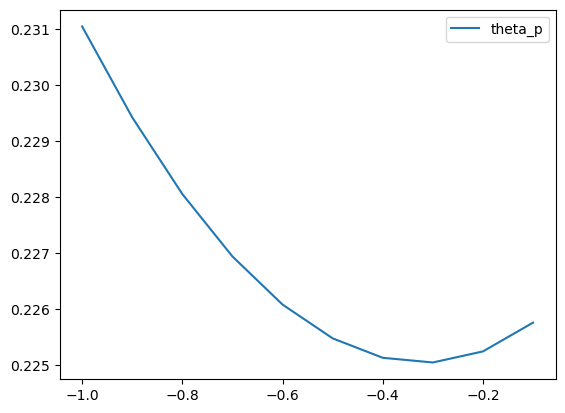

In [35]:
import matplotlib.pyplot as plt

theta_p_grid= np.arange(-1, 0, 0.1)

obj_theta_p = [LL([i, 0.2, -3, -6]) for i in theta_p_grid]


plt.plot(theta_p_grid, obj_theta_p, label="theta_p")

plt.legend()


plt.show()

[LL] Outer iteration #1 with params [-0.3, 1, np.float64(-0.8), -1]
[SQUAREM Iter 0] max update = 3.42342e-01, step_len = -1.00
[SQUAREM Iter 1] max update = 5.27085e-02, step_len = -2.72
[SQUAREM Iter 2] max update = 5.31773e-02, step_len = -3.20
[SQUAREM Iter 3] max update = 4.49156e-03, step_len = -1.16
[SQUAREM Iter 4] max update = 7.25252e-04, step_len = -4.00
[SQUAREM Iter 5] max update = 2.39674e-04, step_len = -1.13
[SQUAREM Iter 6] max update = 1.30626e-04, step_len = -5.43
[SQUAREM Iter 7] max update = 3.63578e-06, step_len = -1.31
[SQUAREM Iter 8] max update = 1.60656e-06, step_len = -2.65
[SQUAREM Iter 9] max update = 4.69498e-08, step_len = -1.08
[LL] Outer iteration #1 with params [-0.3, 1, np.float64(-0.7000000000000001), -1]
[SQUAREM Iter 0] max update = 3.42389e-01, step_len = -1.00
[SQUAREM Iter 1] max update = 5.27992e-02, step_len = -2.71
[SQUAREM Iter 2] max update = 5.35996e-02, step_len = -3.18
[SQUAREM Iter 3] max update = 4.64330e-03, step_len = -1.16
[SQUAREM 

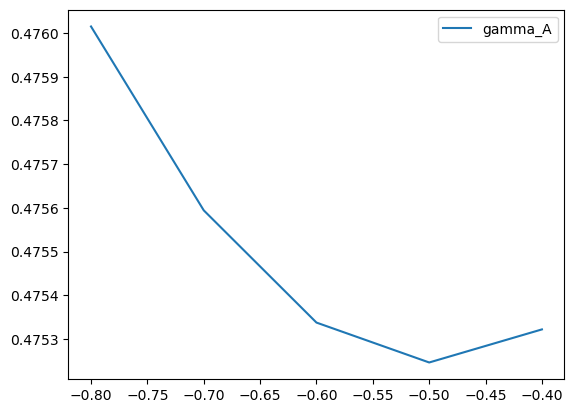

In [58]:
gamma_A_grid= np.arange(-0.8, -0.3, 0.1)

obj_gamma_A= [bulk_estimation(1, [-0.3, 1, i, -1], 50, 123) for i in gamma_A_grid]

plt.plot(gamma_A_grid, obj_gamma_A, label="gamma_A")

plt.legend()

plt.show()

[LL] Outer iteration #1 with params [-0.3, 1, -0.5, np.int64(-5)]
[SQUAREM Iter 0] max update = 4.22520e-01, step_len = -1.00
[SQUAREM Iter 1] max update = 3.08990e-01, step_len = -3.46
[SQUAREM Iter 2] max update = 1.58328e-01, step_len = -2.73
[SQUAREM Iter 3] max update = 1.54989e-01, step_len = -2.55
[SQUAREM Iter 4] max update = 4.70119e-02, step_len = -1.46
[SQUAREM Iter 5] max update = 1.21746e-01, step_len = -4.00
[SQUAREM Iter 6] max update = 2.12485e-02, step_len = -1.18
[SQUAREM Iter 7] max update = 8.68582e-02, step_len = -12.74
[SQUAREM Iter 8] max update = 9.01414e-04, step_len = -1.10
[SQUAREM Iter 9] max update = 8.91888e-04, step_len = -4.68
[SQUAREM Iter 10] max update = 1.35507e-04, step_len = -1.75
[SQUAREM Iter 11] max update = 4.85875e-04, step_len = -3.71
[SQUAREM Iter 12] max update = 5.84130e-05, step_len = -1.13
[SQUAREM Iter 13] max update = 8.26977e-05, step_len = -12.37
[SQUAREM Iter 14] max update = 5.09470e-06, step_len = -1.20
[SQUAREM Iter 15] max updat

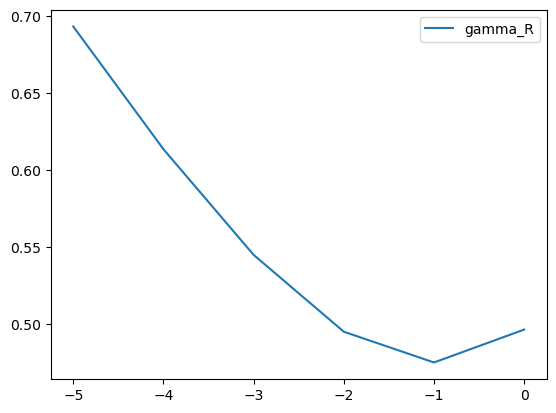

In [60]:
gamma_R_grid= np.arange(-5, 1, 1)

obj_gamma_R= [bulk_estimation(1, [-0.3, 1, -0.5, i], 50, 123) for i in gamma_R_grid]

plt.plot(gamma_R_grid, obj_gamma_R, label="gamma_R")

plt.legend()

plt.show()

In [19]:
bounds = [
    (None, 0.0),
    (0.0, None),  # no bounds for eta
    (None, 0.0),   # gamma_A <= 0
    (None, 0.0)    # gamma_R <= 0
]

In [21]:
def objective(params):
    return estimation(0, params, 50, 35)

In [27]:
init = [-1, 1, -1, -2]
ITERATION=[0]
def callback(xk):
    ITERATION[0]+=1
    #grad_approx = approx_fprime(xk, objective_first, epsilon)
    #norm_grad = np.linalg.norm(grad_approx)
    print(f"ITERATION {ITERATION[0]}:  f(x) = {objective[xk]}, estimates = {xk[:3]}")

result = minimize(objective, x0=init,  method='L-BFGS-B', jac=None, options={'eps': 1e-3, 'disp': True, 'maxiter': 10000, 'gtol': 1e-8, 'ftol':1e-13})

[LL] Outer iteration #1 with params [-1.  1. -1. -2.]
[SQUAREM Iter 0] max update = 6.31977e-01, step_len = -1.00
[SQUAREM Iter 1] max update = 1.42588e-01, step_len = -3.08
[SQUAREM Iter 2] max update = 2.77818e-01, step_len = -3.48
[SQUAREM Iter 3] max update = 3.21062e-02, step_len = -1.17
[SQUAREM Iter 4] max update = 1.18158e-02, step_len = -4.00
[SQUAREM Iter 5] max update = 7.54519e-03, step_len = -1.86
[SQUAREM Iter 6] max update = 5.96889e-03, step_len = -1.96
[SQUAREM Iter 7] max update = 2.70275e-03, step_len = -1.66
[SQUAREM Iter 8] max update = 4.82815e-03, step_len = -2.55
[SQUAREM Iter 9] max update = 1.16781e-03, step_len = -1.20
[SQUAREM Iter 10] max update = 6.53570e-03, step_len = -8.57
[SQUAREM Iter 11] max update = 3.14684e-05, step_len = -1.03
[SQUAREM Iter 12] max update = 9.71059e-05, step_len = -10.27
[SQUAREM Iter 13] max update = 4.85948e-07, step_len = -1.02
[SQUAREM Iter 14] max update = 3.41029e-07, step_len = -2.68
[SQUAREM Iter 15] max update = 1.23824e-

Exception ignored in: <function ResourceTracker.__del__ at 0x1033709a0>
Traceback (most recent call last):
  File "/Users/fangyuan/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/fangyuan/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/fangyuan/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103df49a0>
Traceback (most recent call last):
  File "/Users/fangyuan/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/fangyuan/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/fangyuan/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception igno

[SQUAREM Iter 2] max update = 3.26298e-04, step_len = -2.24
[SQUAREM Iter 3] max update = 1.66254e-04, step_len = -1.83
[SQUAREM Iter 4] max update = 1.53744e-04, step_len = -2.64
[SQUAREM Iter 5] max update = 5.47841e-05, step_len = -1.51
[SQUAREM Iter 6] max update = 1.18421e-04, step_len = -4.23
[SQUAREM Iter 7] max update = 1.37919e-05, step_len = -1.20
[SQUAREM Iter 8] max update = 6.06367e-05, step_len = -9.01
[SQUAREM Iter 9] max update = 2.56772e-07, step_len = -1.10
[SQUAREM Iter 10] max update = 4.13637e-07, step_len = -7.52
[SQUAREM Iter 11] max update = 1.72250e-08, step_len = -1.19
[LL] Outer iteration #8 with params [-0.01138758  0.9111795  -0.9634584  -1.88492402]
[SQUAREM Iter 0] max update = 1.48925e-03, step_len = -1.00
[SQUAREM Iter 1] max update = 4.39750e-04, step_len = -4.00
[SQUAREM Iter 2] max update = 3.32529e-04, step_len = -2.29
[SQUAREM Iter 3] max update = 1.61193e-04, step_len = -1.78
[SQUAREM Iter 4] max update = 1.61824e-04, step_len = -2.80


Exception ignored in: <function ResourceTracker.__del__ at 0x1040709a0>
Traceback (most recent call last):
  File "/Users/fangyuan/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/fangyuan/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/fangyuan/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[SQUAREM Iter 5] max update = 5.13624e-05, step_len = -1.45
[SQUAREM Iter 6] max update = 1.39006e-04, step_len = -4.81
[SQUAREM Iter 7] max update = 1.11753e-05, step_len = -1.17
[SQUAREM Iter 8] max update = 4.33515e-05, step_len = -9.58
[SQUAREM Iter 9] max update = 8.70472e-08, step_len = -1.10
[LL] Outer iteration #9 with params [-0.01138758  0.9101795  -0.9624584  -1.88492402]
[SQUAREM Iter 0] max update = 5.23386e-05, step_len = -1.00
[SQUAREM Iter 1] max update = 6.85402e-05, step_len = -3.48
[SQUAREM Iter 2] max update = 1.43903e-05, step_len = -1.15
[SQUAREM Iter 3] max update = 5.59930e-06, step_len = -4.00
[SQUAREM Iter 4] max update = 1.18325e-05, step_len = -4.69
[SQUAREM Iter 5] max update = 1.35590e-06, step_len = -1.26
[SQUAREM Iter 6] max update = 5.59551e-07, step_len = -10.55
[SQUAREM Iter 7] max update = 1.71726e-08, step_len = -1.18
[LL] Outer iteration #10 with params [-0.01138758  0.9101795  -0.9634584  -1.88392402]
[SQUAREM Iter 0] max update = 5.18115e-05, ste

Exception ignored in: <function ResourceTracker.__del__ at 0x10286c9a0>
Traceback (most recent call last):
  File "/Users/fangyuan/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/fangyuan/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/fangyuan/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[SQUAREM Iter 3] max update = 1.59255e-04, step_len = -1.72
[SQUAREM Iter 4] max update = 2.01445e-04, step_len = -3.09
[SQUAREM Iter 5] max update = 4.69154e-05, step_len = -1.36
[SQUAREM Iter 6] max update = 1.57654e-04, step_len = -5.67
[SQUAREM Iter 7] max update = 7.48070e-06, step_len = -1.14
[SQUAREM Iter 8] max update = 3.42426e-05, step_len = -9.45
[SQUAREM Iter 9] max update = 7.13244e-08, step_len = -1.07
[LL] Outer iteration #19 with params [-0.31091463  0.85836047 -0.9550787  -1.97968541]
[SQUAREM Iter 0] max update = 5.05894e-05, step_len = -1.00
[SQUAREM Iter 1] max update = 5.28582e-05, step_len = -3.39
[SQUAREM Iter 2] max update = 1.47442e-05, step_len = -1.17
[SQUAREM Iter 3] max update = 5.74908e-06, step_len = -4.00
[SQUAREM Iter 4] max update = 5.59601e-06, step_len = -4.29
[SQUAREM Iter 5] max update = 1.55429e-06, step_len = -1.33
[SQUAREM Iter 6] max update = 5.41544e-06, step_len = -8.64
[SQUAREM Iter 7] max update = 2.35581e-07, step_len = -1.10
[SQUAREM Iter

In [28]:
result

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.6907405126676079
        x: [-2.950e-01  4.585e-01 -1.015e+00 -2.023e+00]
      nit: 16
      jac: [ 1.021e-08  9.553e-10  1.265e-09 -2.438e-09]
     nfev: 250
     njev: 50
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>